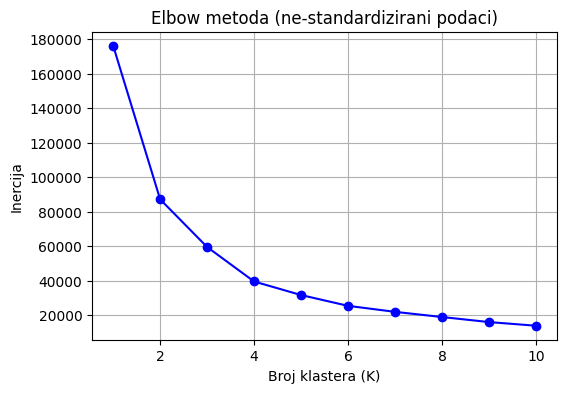

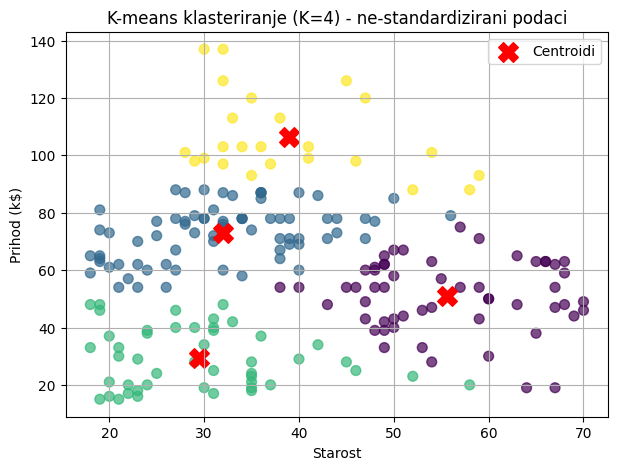

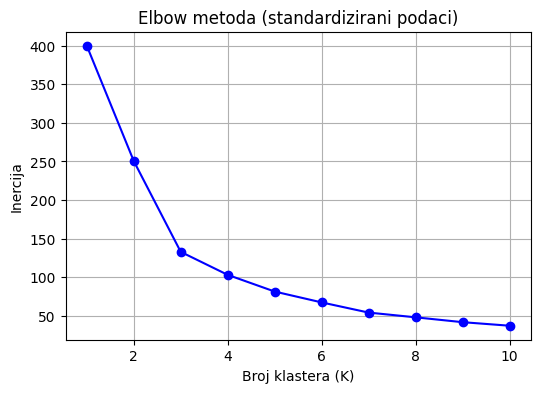

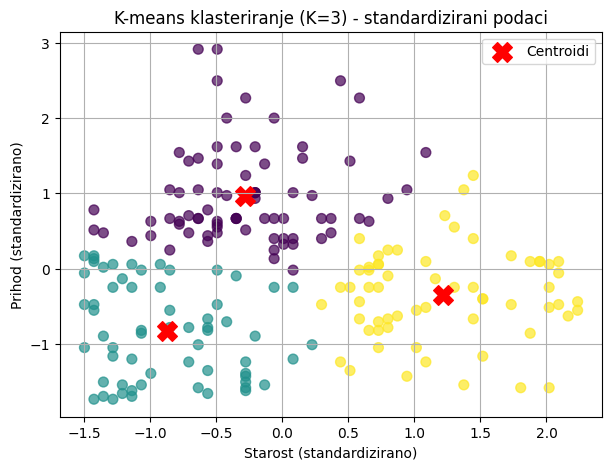

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
data = pd.read_csv("Mall_Customers.csv")
X = data[['Age', 'Annual Income (k$)']]
inertia = []
K_values = range(1, 11)
for k in K_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(K_values, inertia, 'bo-')
plt.title("Elbow metoda (ne-standardizirani podaci)")
plt.xlabel("Broj klastera (K)")
plt.ylabel("Inercija")
plt.grid(True);plt.show()
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
plt.figure(figsize=(7, 5))
plt.scatter(X['Age'], X['Annual Income (k$)'], c=labels, cmap='viridis', s=50, alpha=0.7)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroidi')
plt.title(f"K-means klasteriranje (K={optimal_k}) - ne-standardizirani podaci")
plt.xlabel("Starost")
plt.ylabel("Prihod (k$)")
plt.legend();plt.grid(True);plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia_scaled = []
for k in K_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia_scaled.append(kmeans.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(K_values, inertia_scaled, 'bo-')
plt.title("Elbow metoda (standardizirani podaci)")
plt.xlabel("Broj klastera (K)")
plt.ylabel("Inercija")
plt.grid(True)
plt.show()
optimal_k=3

kmeans_scaled = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_scaled, cmap='viridis', s=50, alpha=0.7)
centers_scaled = kmeans_scaled.cluster_centers_
plt.scatter(centers_scaled[:, 0], centers_scaled[:, 1], c='red', s=200, marker='X', label='Centroidi')
plt.title(f"K-means klasteriranje (K={optimal_k}) - standardizirani podaci")
plt.xlabel("Starost (standardizirano)")
plt.ylabel("Prihod (standardizirano)")
plt.legend()
plt.grid(True)
plt.show()
